# Northbridge Supplies: Invoice Process Data Analysis

This notebook tests what stakeholders told us in interviews against the 2025 invoice data (5,045 invoices). Each section starts with the business question and the stakeholder claim it tests, runs the analysis, and ends with a **finding** written for the Finance Director.



## 0. Setup: load and prepare the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import glob
# Finds the file even if your browser renamed it, e.g. "northbridge_invoices_2025 (1).csv"
csv_path = glob.glob("**/northbridge_invoices_2025*.csv", recursive=True)[0]
df = pd.read_csv(csv_path)

# Turn the date columns into real dates so we can calculate time gaps
date_cols = ["invoice_date", "received_date", "date_logged", "date_sent_for_approval",
             "date_approved", "date_paid", "due_date"]
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

# Time taken at each stage, in days
df["days_to_pay"]      = (df["date_paid"] - df["invoice_date"]).dt.days
df["days_to_log"]      = (df["date_logged"] - df["received_date"]).dt.days
df["days_to_approve"]  = (df["date_approved"] - df["date_sent_for_approval"]).dt.days

# Simple yes/no flags
df["paid_late"]  = df["days_late"] > 0
df["po_problem"] = df["po_match_status"] != "Matched"
days_in_month    = df["received_date"].dt.days_in_month
df["month_end"]  = df["received_date"].dt.day > (days_in_month - 7)   # last 7 days of the month

# Consistent chart style
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False})

print(f"{len(df):,} invoices worth £{df['invoice_amount_gbp'].sum():,.0f}")
df.head()

5,045 invoices worth £20,439,343


,invoice_id,supplier_id,supplier_name,supplier_category,invoice_number,invoice_date,received_date,received_channel,invoice_amount_gbp,po_number,...,query_raised,query_reason,rework_count,approval_reminders_sent,days_to_pay,days_to_log,days_to_approve,paid_late,po_problem,month_end
0,INV00055,SUP041,Pennine South IT Solutions Ltd,IT Services,041-10054,2025-01-02,2025-01-02,Supplier portal,651.58,PO424467,...,True,Price does not match PO,1,0,14,1,0,False,True,False
1,INV00576,SUP027,Beacon South Materials plc,Raw Materials,027-10575,2025-01-02,2025-01-02,Email,2309.26,PO409113,...,False,NaN,0,0,7,0,1,False,False,False
2,INV00715,SUP057,Granite East Creative Ltd,Marketing Services,057-10714,2025-01-02,2025-01-02,Supplier portal,4504.48,PO741472,...,False,NaN,0,1,7,0,5,False,False,False
3,INV00779,SUP011,Kestrel Packaging Ltd,Packaging,011-10778,2025-01-01,2025-01-02,Email,1126.22,PO686355,...,False,NaN,0,0,8,1,3,False,False,False
4,INV01194,SUP056,Fairview East Creative Ltd,Marketing Services,056-11193,2025-01-01,2025-01-02,Supplier portal,428.41,PO554977,...,False,NaN,0,0,8,0,4,False,False,False


## 1. How big is the problem?

**Business question:** how far is Northbridge from the Finance Director's targets?

**Target (from the brief):** at least 95% of invoices paid on time.

In [2]:
on_time_rate  = 1 - df["paid_late"].mean()
late_charges  = df["late_payment_charge_gbp"].sum()
avg_days      = df["days_to_pay"].mean()

print(f"Paid on time:               {on_time_rate:.1%}   (target 95%)")
print(f"Invoices paid late:         {df['paid_late'].sum():,}")
print(f"Late-payment charges:       £{late_charges:,.0f}")
print(f"Average invoice to payment: {avg_days:.1f} days")

Paid on time:               82.1%   (target 95%)
Invoices paid late:         904
Late-payment charges:       £17,597
Average invoice to payment: 21.0 days


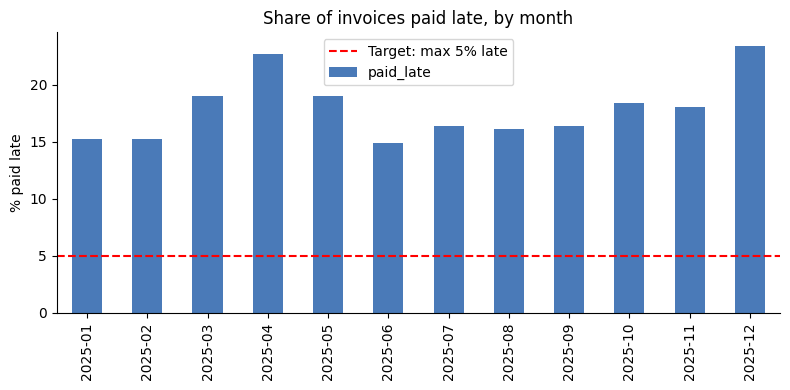

In [3]:
monthly = df.groupby(df["invoice_date"].dt.to_period("M"))["paid_late"].mean() * 100
ax = monthly.plot(kind="bar", color="#4a7ab8")
ax.axhline(5, color="red", linestyle="--", label="Target: max 5% late")
ax.set_title("Share of invoices paid late, by month")
ax.set_ylabel("% paid late"); ax.set_xlabel("")
ax.legend(); plt.tight_layout(); plt.show()

**Finding:** Only 82.1% of invoices were paid on time in 2025, well short of the 95% target. That meant 904 invoices were paid late, costing £17,597 in late-payment charges, and on average it took 21 days to pay an invoice. No month came close to the target, and April and December were the worst, with more than 1 in 5 invoices paid late.

## 2. Purchase order problems

**Claim to test (Daniel):** "About 1 in 4 invoices has some kind of PO problem."
**Claim to test (Mark):** invoices without a PO or with a price difference stall.

In [4]:
po_share = df["po_match_status"].value_counts(normalize=True).mul(100).round(1)
print("Share of invoices by PO status (%):"); print(po_share, "\n")

po_summary = df.groupby("po_match_status").agg(
    invoices=("invoice_id", "count"),
    avg_days_to_pay=("days_to_pay", "mean"),
    pct_late=("paid_late", lambda s: s.mean() * 100),
).round(2)
po_summary

Share of invoices by PO status (%):
po_match_status
Matched           71.9
No PO             19.4
Price mismatch     8.8
Name: proportion, dtype: float64 



,invoices,avg_days_to_pay,pct_late
po_match_status,,,
Matched,3625,17.45,10.62
No PO,977,29.38,33.98
Price mismatch,443,31.24,42.21


In [5]:
late = df[df["paid_late"]]
print(f"Share of LATE invoices with a PO problem: {late['po_problem'].mean():.1%}")

Share of LATE invoices with a PO problem: 57.4%


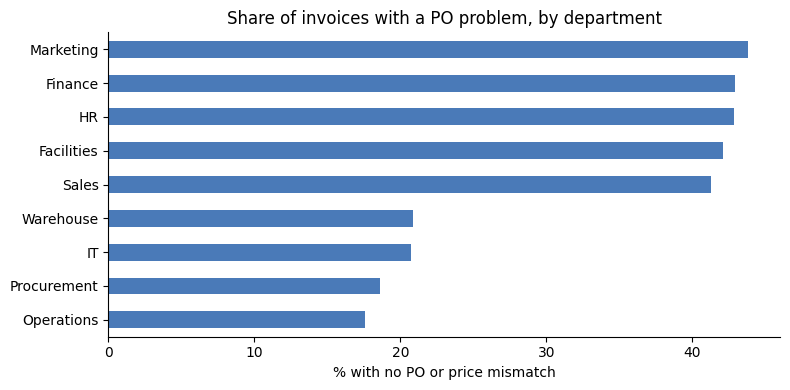

In [6]:
dept_po = (df.groupby("department")["po_problem"].mean() * 100).sort_values()
ax = dept_po.plot(kind="barh", color="#4a7ab8")
ax.set_title("Share of invoices with a PO problem, by department")
ax.set_xlabel("% with no PO or price mismatch"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Finding:** Daniel's estimate was close. 28% of invoices had a PO problem (19.4% with no PO and 8.8% with a price mismatch), slightly more than 1 in 4. These invoices took around 30 days to pay compared with 17 days for matched ones, and they account for 57% of all late payments, making them the biggest single cause. The worst departments were Marketing, Finance, HR, Facilities and Sales, where over 40% of invoices had a PO problem. Interestingly, Operations was one of the best, at 17.6%.

## 3. Approvers

**Claim to test (Daniel):** "Some managers approve the same day; others we chase three or four times."
**Claim to test (Mark):** approvals are batched and can sit for weeks.

*Tip: compare approvers on the **same kind** of invoice. Here we use only matched invoices, so PO problems don't distort the comparison.*

In [7]:
matched = df[df["po_match_status"] == "Matched"]
approvers = matched.groupby("budget_holder_role").agg(
    invoices=("invoice_id", "count"),
    avg_days_to_approve=("days_to_approve", "mean"),
    pct_late=("paid_late", lambda s: s.mean() * 100),
).round(1)

# Reminders and charges use ALL invoices
all_inv = df.groupby("budget_holder_role").agg(
    reminders=("approval_reminders_sent", "sum"),
    late_charges_gbp=("late_payment_charge_gbp", "sum"),
).round(0)
approvers.join(all_inv).sort_values("avg_days_to_approve", ascending=False)

,invoices,avg_days_to_approve,pct_late,reminders,late_charges_gbp
budget_holder_role,,,,,
Operations Manager,960,15.0,21.5,3551,11407.0
Marketing Manager,223,11.8,18.8,998,0.0
HR Manager,88,4.6,13.6,76,73.0
Sales Director,323,4.4,7.1,299,73.0
IT Manager,563,4.2,11.9,353,3044.0
Procurement Lead,467,4.1,3.6,327,2070.0
Facilities Manager,411,2.9,0.7,171,353.0
Warehouse Manager,509,2.7,2.6,141,577.0
Financial Controller,81,2.4,2.5,39,0.0


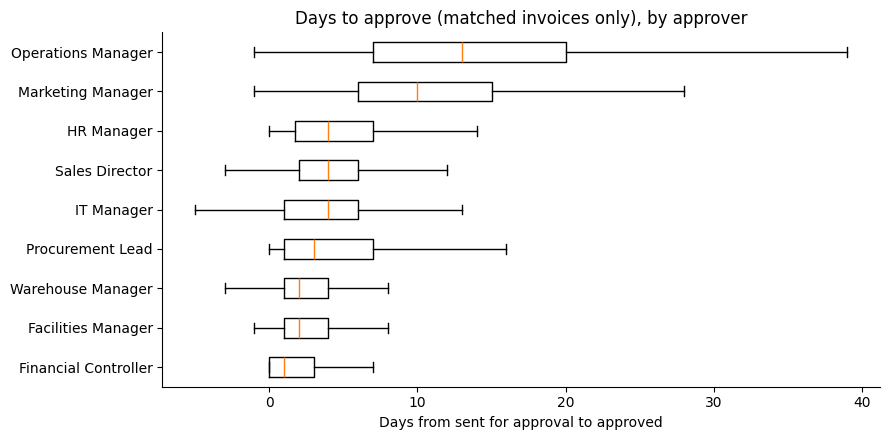

In [8]:
order = matched.groupby("budget_holder_role")["days_to_approve"].median().sort_values().index
data  = [matched.loc[matched["budget_holder_role"] == r, "days_to_approve"] for r in order]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(data, vert=False, showfliers=False)
ax.set_yticklabels(order)
ax.set_title("Days to approve (matched invoices only), by approver")
ax.set_xlabel("Days from sent for approval to approved")
plt.tight_layout(); plt.show()

**Do reminders work?** If reminders sped approvals up, invoices with more reminders would not take much longer.

In [9]:
df.groupby("approval_reminders_sent")["days_to_approve"].agg(["count", "mean"]).round(1)

,count,mean
approval_reminders_sent,,
0,2581,2.0
1,1108,6.2
2,572,10.4
3,279,14.9
4,179,19.2
5,128,23.6
6,79,27.7
7,48,31.7
8,25,36.8


**Finding:** Two approvers stand out. Even on straightforward matched invoices, the Operations Manager took 15 days on average to approve and the Marketing Manager took 12, compared with under 5 days for everyone else. One in ten of the Operations Manager's invoices took four weeks or more, which supports Mark's comment that invoices can sit for weeks. His invoices also received 3,551 reminders (60% of the total) and led to £11,407 of late charges (65% of the total).

On reminders, the data can't tell us whether they work. Invoices with more reminders took longer, but that's because reminders are only sent when an invoice is already slow. What we can say is that 2,464 invoices needed at least one reminder, which is a lot of manual chasing.

## 4. Month-end backlog

**Claim to test (Daniel):** "The last week of the month is chaos… we can't log them fast enough."

In [10]:
me = df.groupby("month_end").agg(
    invoices=("invoice_id", "count"),
    avg_days_to_log=("days_to_log", "mean"),
    pct_late=("paid_late", lambda s: s.mean() * 100),
).round(2)
me.index = me.index.map({False: "Rest of month", True: "Last 7 days"})
me

,invoices,avg_days_to_log,pct_late
month_end,,,
Rest of month,2936,1.41,14.31
Last 7 days,2109,6.65,22.95


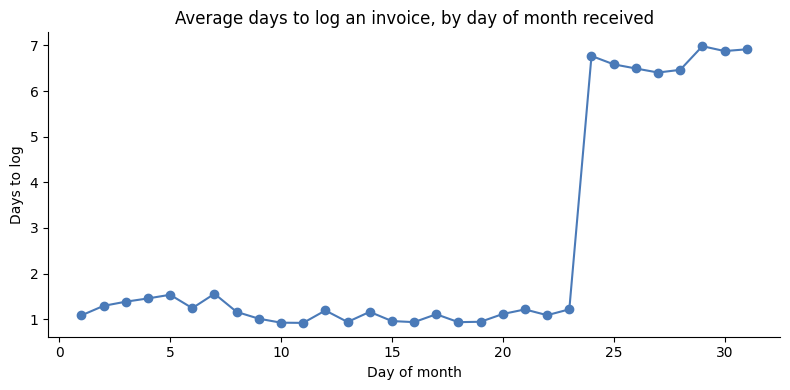

In [11]:
by_day = df.groupby(df["received_date"].dt.day)["days_to_log"].mean()
ax = by_day.plot(marker="o", color="#4a7ab8")
ax.set_title("Average days to log an invoice, by day of month received")
ax.set_xlabel("Day of month"); ax.set_ylabel("Days to log")
plt.tight_layout(); plt.show()

**Finding:** Daniel is right about month-end. 42% of the year's invoices arrive in the last 7 days of the month, and they take 6.7 days to log, compared with 1.4 days the rest of the month. As a result, 22.9% of month-end invoices were paid late, compared with 14.3% at other times.

## 5. How invoices arrive

**Claim to test (Daniel):** posted invoices are slow and easy to lose; portal invoices are easiest.

In [12]:
ch = df.groupby("received_channel").agg(
    invoices=("invoice_id", "count"),
    avg_days_received=( "received_date", lambda s: (s - df.loc[s.index, "invoice_date"]).dt.days.mean()),
    avg_days_to_log=("days_to_log", "mean"),
    avg_days_to_pay=("days_to_pay", "mean"),
    pct_late=("paid_late", lambda s: s.mean() * 100),
).round(1)
ch

,invoices,avg_days_received,avg_days_to_log,avg_days_to_pay,pct_late
received_channel,,,,,
Email,3635,1.0,3.4,20.6,17.7
Post,664,5.0,4.8,24.0,21.2
Supplier portal,746,0.2,3.4,20.3,16.0


**Finding:** Posted invoices are slower, but the difference is smaller than Daniel suggested. They arrive about 5 days after the invoice date, compared with 1 day by email, and take 24 days to pay, against about 20 days for email and the portal. 21.2% of posted invoices were paid late, compared with 16.0% for the portal. Post is only 13% of invoices (664), so moving suppliers to the portal helps, but it isn't the main problem.

## 6. The £10,000 second approval

**Question:** how much time does the Finance Director's second approval add?

In [13]:
lvl = df.groupby("approval_levels_required").agg(
    invoices=("invoice_id", "count"),
    avg_days_to_approve=("days_to_approve", "mean"),
    pct_late=("paid_late", lambda s: s.mean() * 100),
).round(1)
lvl.index = lvl.index.map({1: "Under £10k (1 approval)", 2: "£10k+ (2 approvals)"})
lvl

,invoices,avg_days_to_approve,pct_late
approval_levels_required,,,
Under £10k (1 approval),4509,6.3,17.0
£10k+ (2 approvals),536,13.2,25.7


**Finding:** The second approval roughly doubles approval time, from 6.3 days to 13.2 days. It applies to 536 invoices of £10,000 or more, and 25.7% of them were paid late, compared with 17.0% of smaller invoices. This matters because these are usually our biggest suppliers, and late payments to them carry the greatest risk of being put on stop.

## 7. The cost of chasing

**Claim to test (Daniel):** "One of my team spends about a day a week just sending reminders and waiting for replies."

**Assumptions from the brief:** AP staff cost £18/hour · 10 minutes per reminder · 45 minutes per query. One day a week ≈ 7.5 hours × 52 weeks ≈ 390 hours a year.

In [14]:
HOURLY, MIN_REMINDER, MIN_QUERY = 18, 10, 45

reminders = df["approval_reminders_sent"].sum()
queries   = df["query_raised"].sum()
rem_hours = reminders * MIN_REMINDER / 60
q_hours   = queries * MIN_QUERY / 60

print(f"Reminders sent: {reminders:,}  →  {rem_hours:,.0f} hours  →  £{rem_hours*HOURLY:,.0f}")
print(f"Queries raised: {queries:,}  →  {q_hours:,.0f} hours  →  £{q_hours*HOURLY:,.0f}")
print(f"Total:                         {rem_hours+q_hours:,.0f} hours  →  £{(rem_hours+q_hours)*HOURLY:,.0f}")
print(f"\nDaniel's 'day a week' ≈ 390 hours a year")

Reminders sent: 5,955  →  992 hours  →  £17,865
Queries raised: 1,567  →  1,175 hours  →  £21,154
Total:                         2,168 hours  →  £39,020

Daniel's 'day a week' ≈ 390 hours a year


In [15]:
df["query_reason"].value_counts()

query_reason
Missing PO number          977
Price does not match PO    443
Incorrect VAT               57
Wrong cost centre           47
Goods not received          43
Name: count, dtype: int64

**Finding:** Daniel underestimated it. Reminders and queries took about 2,168 hours of staff time in 2025, costing around £39,020. That's more than five times his "day a week" (about 390 hours), and more than one person's full working year. Nine out of ten queries came from PO problems (missing PO or price mismatch), so fixing POs at the start of the process would also cut most of the query work.

## 8. Duplicate payments

**Claim to test (Daniel):** "I wouldn't be surprised if we've paid a few twice without knowing."
**Link to the brief:** the external auditors asked for stronger controls to detect duplicate invoices.

A duplicate here means the **same supplier and the same supplier invoice number** paid more than once.

In [16]:
key = ["supplier_id", "invoice_number"]
dupes = df[df.duplicated(subset=key, keep=False)].sort_values(key + ["date_paid"])

# The first payment is legitimate; every extra copy is money paid twice
extra = df[df.duplicated(subset=key, keep="first")]

print(f"Invoice numbers paid more than once: {dupes.groupby(key).ngroups}")
print(f"Extra (duplicate) payments:          {len(extra)}")
print(f"Value paid twice:                    £{extra['invoice_amount_gbp'].sum():,.0f}")
dupes[["supplier_name", "invoice_number", "invoice_amount_gbp", "received_channel", "date_paid"]].head(10)

Invoice numbers paid more than once: 45
Extra (duplicate) payments:          45
Value paid twice:                    £158,776


,supplier_name,invoice_number,invoice_amount_gbp,received_channel,date_paid
3956,Albion Packaging Ltd,001-13797,1979.70,Email,2025-10-23
4075,Albion Packaging Ltd,001-13797,1979.70,Email,2025-11-03
2348,Castle Packaging Ltd,003-10940,3081.50,Email,2025-07-24
2541,Castle Packaging Ltd,003-10940,3081.50,Email,2025-08-04
3118,Dunmore Packaging Ltd,004-10261,310.42,Email,2025-08-21
3314,Dunmore Packaging Ltd,004-10261,310.42,Email,2025-09-01
2784,Dunmore Packaging Ltd,004-11270,544.18,Email,2025-08-21
3031,Dunmore Packaging Ltd,004-11270,544.18,Email,2025-09-01
936,Fairview Packaging Ltd,006-11412,1744.58,Email,2025-03-20
1052,Fairview Packaging Ltd,006-11412,1744.58,Email,2025-03-31


**Finding:** This is the most serious finding. 45 invoices were paid twice, costing £158,776, which is about nine times the late-payment charges. In every case the second payment went out 11 days after the first, and most duplicates arrived by email, which fits Daniel's point that suppliers resend invoices when chasing. This confirms the auditors' concern: there is currently no control to stop the same invoice being paid twice. The money may be recoverable from suppliers and should be followed up.

## 9. Summary: claims vs evidence

| Claim | Who | Supported by the data? | Evidence |
|---|---|---|---|
| About 1 in 4 invoices has a PO problem | Daniel | Yes, slightly more | 28% of invoices |
| Some approvers are much slower | Daniel / Mark | Yes | Operations Manager 15 days vs under 5 for most |
| Month-end causes a logging backlog | Daniel | Yes | 6.7 days to log vs 1.4 |
| Posted invoices are slower | Daniel | Yes, but a small effect | 24 days to pay vs about 20 |
| About a day a week spent chasing | Daniel | Underestimated | 2,168 hours (about £39,020) a year |
| Some invoices may have been paid twice | Daniel | Yes | 45 invoices, £158,776 |

**Top 3 root causes for the Finance Director:**
1. **Missing and mismatched POs.** They affect 28% of invoices, account for 57% of late payments, and cause 9 out of 10 queries.
2. **Slow approvals from two budget holders.** The Operations and Marketing Managers take 3 to 5 times longer than other approvers, mainly because approvals arrive by email without the PO and delivery information needed to approve with confidence.
3. **No duplicate payment check.** £158,776 was paid twice in one year, confirming the auditors' concern.